# 📊 FFT 주파수 분석 (Fast Fourier Transform)

> **학습 목표**: FFT를 사용하여 진동 신호의 주파수 특성을 분석합니다.

---

## 📋 학습 내용

1. ✅ FFT (Fast Fourier Transform) 개념
2. ✅ 시계열 데이터 → 주파수 도메인 변환
3. ✅ 주파수 스펙트럼 시각화
4. ✅ 지배 주파수 (Dominant Frequency) 찾기
5. ✅ 이상 주파수 탐지
6. ✅ Spectrogram (시간-주파수 분석)

**소요 시간**: 약 35분  
**난이도**: ⭐⭐⭐ (중상급)  
**사전 지식**: 시계열 분석 기초, NumPy

---

## 🔧 Step 1: 라이브러리 Import

In [1]:
# 데이터 분석
import pandas as pd
import numpy as np

# 신호 처리
from scipy.fft import fft, fftfreq, rfft, rfftfreq
from scipy.signal import find_peaks, spectrogram, welch

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

# 유틸리티
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (14, 6)

print("✅ 라이브러리 로드 완료!")

✅ 라이브러리 로드 완료!


## 📂 Step 2: 진동 데이터 로드

In [2]:
# ============================================================
# 📂 KAMP 실제 데이터 로드 (FordEngine 엔진 진동 시계열)
# ============================================================
# 우선순위: KAMP FordEngine 실제 데이터 → 샘플 데이터 (fallback)
#
# FordA_TEST.txt 구조:
#   - 공백 구분, 헤더 없음
#   - 첫 번째 열: 레이블 (-1=정상, 1=고장)
#   - 나머지 500열: 엔진 진동 시계열 데이터
#   - 1,320행 × 501열 (TEST 데이터)
#   - FFT 주파수 분석에 최적화된 시계열 데이터
#
# 참고: FordA_TRAIN.txt는 파일 손상(null padding)으로
#       FordA_TEST.txt를 우선 사용합니다.
# ============================================================

from pathlib import Path

# KAMP 실제 데이터 경로 (FordEngine)
kamp_ford_test = Path('../../dataset/part2-1/FordEngine/FordA_TEST.txt')
kamp_ford_train = Path('../../dataset/part2-1/FordEngine/FordA_TRAIN.txt')
fallback_path = Path('../data/sample_kamp_vibration.csv')

def load_ford_data(file_path):
    """FordA 엔진 진동 데이터 로드 (공백 구분, 헤더 없음)"""
    raw = np.loadtxt(file_path)
    labels = raw[:, 0].astype(int)    # 첫 번째 열: 레이블
    signals = raw[:, 1:]               # 나머지: 시계열 데이터
    
    # DataFrame 구성: 레이블 + 시계열 컬럼
    cols = ['label'] + [f't_{i}' for i in range(signals.shape[1])]
    df = pd.DataFrame(
        np.column_stack([labels, signals]),
        columns=cols
    )
    df['label'] = df['label'].astype(int)
    return df, labels, signals

def load_csv_data(file_path):
    """다중 인코딩 시도로 안전한 CSV 로드"""
    encodings = ['utf-8-sig', 'cp949', 'utf-8']
    for encoding in encodings:
        try:
            df = pd.read_csv(file_path, encoding=encoding)
            print(f"✅ 데이터 로드 성공! (인코딩: {encoding})")
            return df
        except:
            continue
    raise ValueError("데이터 로드 실패")

# KAMP FordEngine 데이터 우선 로드
if kamp_ford_test.exists():
    print(f"📂 KAMP FordEngine 실제 데이터 발견: {kamp_ford_test}")
    df, ford_labels, ford_signals = load_ford_data(kamp_ford_test)
    data_source = "KAMP 실제 데이터 (FordEngine/FordA_TEST.txt)"
    use_ford = True
    
    n_normal = (ford_labels == -1).sum()
    n_fault = (ford_labels == 1).sum()
    print(f"✅ 데이터 로드 성공!")
    print(f"\n📋 FordEngine 데이터 구성:")
    print(f"   총 샘플: {len(ford_labels):,}개")
    print(f"   시계열 길이: {ford_signals.shape[1]}포인트/샘플")
    print(f"   정상 (-1): {n_normal:,}개 ({n_normal/len(ford_labels)*100:.1f}%)")
    print(f"   고장 (+1): {n_fault:,}개 ({n_fault/len(ford_labels)*100:.1f}%)")
elif fallback_path.exists():
    print(f"⚠️ FordEngine 데이터 없음 → 샘플 데이터 사용: {fallback_path}")
    df = load_csv_data(fallback_path)
    data_source = "샘플 데이터 (sample_kamp_vibration.csv)"
    use_ford = False
else:
    raise FileNotFoundError("❌ 데이터 파일을 찾을 수 없습니다.")

print(f"\n🏷️ 데이터 소스: {data_source}")
print(f"📊 데이터 크기: {df.shape[0]:,}행 × {df.shape[1]}열")
print(f"💾 메모리 사용량: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# 데이터 미리보기
df.head()

⚠️ FordEngine 데이터 없음 → 샘플 데이터 사용: ../data/sample_kamp_vibration.csv
✅ 데이터 로드 성공! (인코딩: utf-8-sig)

🏷️ 데이터 소스: 샘플 데이터 (sample_kamp_vibration.csv)
📊 데이터 크기: 10,000행 × 10열
💾 메모리 사용량: 2.88 MB


,측정시간,설비ID,센서위치,RMS_velocity_mm_s,Peak_acceleration_g,Kurtosis,Crest_factor,온도_C,RPM,상태
0,2024-01-01 00:00:00,PUMP-001,Housing,1.876966,1.439068,4.112336,5.526823,50.505106,1498.820704,주의
1,2024-01-01 00:01:00,FAN-001,Housing,2.016505,1.457427,3.467688,5.562531,47.961060,1478.933815,주의
2,2024-01-01 00:02:00,MOTOR-001,Housing,1.018292,1.692861,3.504745,5.143902,43.085359,1497.430878,정상
3,2024-01-01 00:03:00,PUMP-001,NDE_Bearing,1.460211,1.158087,3.800483,3.579926,43.090063,1489.458298,주의
4,2024-01-01 00:04:00,PUMP-001,Housing,1.789774,1.383111,3.098036,3.470041,41.872592,1472.350275,주의


In [3]:
# ============================================================
# 옵션: CWRU 베어링 데이터셋 (.mat 파일) 로딩
# 슬라이드 실습: scipy.io.loadmat('97.mat')
# 다운로드: https://engineering.case.edu/bearingdatacenter
# ============================================================
import scipy.io

cwru_paths = [
    '../data/cwru/97.mat',
    '../../dataset/cwru/97.mat',
    './97.mat'
]

cwru_data = None
for cwru_path in cwru_paths:
    if Path(cwru_path).exists():
        try:
            cwru_data = scipy.io.loadmat(cwru_path)
            print(f"✅ CWRU 데이터 로드 완료: {cwru_path}")
            print(f"   키: {[k for k in cwru_data.keys() if not k.startswith('_')]}")
            break
        except Exception as e:
            print(f"⚠️ 로드 실패: {e}")

if cwru_data is None:
    print("ℹ️ CWRU .mat 파일을 찾을 수 없습니다.")
    print("   다운로드: https://engineering.case.edu/bearingdatacenter")
    print("   파일을 ../data/cwru/97.mat 에 저장하면 자동으로 로드됩니다.")
    print("   현재 실습은 KAMP 합성 데이터로 계속 진행합니다.")


ℹ️ CWRU .mat 파일을 찾을 수 없습니다.
   다운로드: https://engineering.case.edu/bearingdatacenter
   파일을 ../data/cwru/97.mat 에 저장하면 자동으로 로드됩니다.
   현재 실습은 KAMP 합성 데이터로 계속 진행합니다.


In [4]:
# 진동 신호 추출 (FordEngine vs 일반 CSV 분기)
if 'use_ford' in dir() and use_ford:
    # FordEngine 데이터: 각 행이 하나의 시계열 (500 포인트)
    # 첫 번째 정상 샘플과 첫 번째 고장 샘플 선택
    normal_idx = np.where(ford_labels == -1)[0][0]
    fault_idx = np.where(ford_labels == 1)[0][0]
    
    # 기본 분석용: 첫 번째 정상 샘플의 시계열
    signal = ford_signals[normal_idx]
    vibration_col = f"정상 샘플 #{normal_idx}"
    
    print(f"📊 FordEngine 시계열 데이터:")
    print(f"   분석 대상: {vibration_col}")
    print(f"   시계열 길이: {len(signal)}포인트")
    print(f"   값 범위: [{signal.min():.4f}, {signal.max():.4f}]")
    print(f"   평균: {signal.mean():.4f}")
    print(f"   표준편차: {signal.std():.4f}")
    
    print(f"\n💡 비교용 고장 샘플 #{fault_idx}도 준비됨")
    signal_fault = ford_signals[fault_idx]
    
    # 진동 컬럼 리스트 (후속 셀 호환용)
    vibration_cols = [f't_{i}' for i in range(ford_signals.shape[1])]
else:
    # 일반 CSV: 기존 로직
    vibration_cols = [col for col in df.columns if any(keyword in col.lower() 
                      for keyword in ['vib', 'x', 'y', 'z', '진동', 'accel'])]

    print(f"📊 진동 관련 컬럼: {len(vibration_cols)}개")
    print(vibration_cols)

    if len(vibration_cols) == 0:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        vibration_col = numeric_cols[0] if numeric_cols else df.columns[0]
        print(f"\n⚠️ 진동 컬럼 미발견, 첫 번째 컬럼 사용: {vibration_col}")
    else:
        vibration_col = vibration_cols[0]
        print(f"\n✅ 선택된 진동 컬럼: {vibration_col}")

    signal = df[vibration_col].dropna().values
    print(f"\n📊 신호 정보:")
    print(f"   샘플 수: {len(signal):,}개")
    print(f"   값 범위: [{signal.min():.4f}, {signal.max():.4f}]")
    print(f"   평균: {signal.mean():.4f}")
    print(f"   표준편차: {signal.std():.4f}")

📊 진동 관련 컬럼: 2개
['RMS_velocity_mm_s', 'Peak_acceleration_g']

✅ 선택된 진동 컬럼: RMS_velocity_mm_s

📊 신호 정보:
   샘플 수: 10,000개
   값 범위: [0.3885, 8.9604]
   평균: 2.0337
   표준편차: 0.7686


## 📈 Step 3: 시계열 신호 시각화

In [5]:

# ============================================================
# ⚙️ 샘플링 레이트 설정 (중요: 데이터 소스별 주의사항)
# ============================================================
import math

# FordEngine 데이터는 500포인트 정규화 시계열 — 실제 Hz 정보 없음
# KAMP 진동 데이터는 Test_time 컬럼으로 추정 가능
# 아래는 교육 목적 가정값 (실제 CWRU 베어링은 48,000 Hz 사용)

if 'use_ford' in dir() and use_ford:
    sampling_rate = 1000   # ⚠️ 교육 가정값 — FordEngine 원본은 정규화 인덱스
    SR_NOTE = "⚠️ FordEngine 데이터: sampling_rate=1000 Hz는 교육 목적 가정값\n   (실제 CWRU 베어링 분석은 48,000 Hz 사용)"
else:
    # KAMP 데이터: Test_time 컬럼으로 실제 fs 추정
    try:
        time_col = [c for c in df.columns if 'time' in c.lower() or 'Time' in c]
        if time_col and len(df) > 1:
            dt = pd.to_numeric(df[time_col[0]], errors='coerce').diff().dropna().median()
            sampling_rate = int(1 / dt) if dt and dt > 0 else 1000
        else:
            sampling_rate = 1000
        SR_NOTE = f"추정된 샘플링 레이트: {sampling_rate} Hz (Test_time 기반)"
    except:
        sampling_rate = 1000
        SR_NOTE = "sampling_rate=1000 Hz (기본값)"

duration = len(signal) / sampling_rate
nyquist = sampling_rate / 2

print(f"⚙️ 샘플링 레이트: {sampling_rate} Hz")
print(f"📌 {SR_NOTE}")
print(f"⏱️ 신호 길이: {len(signal)} 포인트 = {duration:.3f} 초")
print(f"🔬 나이퀴스트 주파수: {nyquist} Hz (이 이상 주파수는 분석 불가)")
print()

# ============================================================
# 🔩 CWRU 베어링 결함 주파수 계산 (교육용 이론값)
# 참고: CWRU 6205-2RS JEM SKF 베어링 파라미터
# ============================================================
def compute_bearing_fault_freqs(shaft_rpm, n_balls=9,
                                 pitch_dia_inch=1.537, ball_dia_inch=0.331,
                                 contact_angle_deg=0):
    """
    베어링 결함 주파수 계산 (BPFI / BPFO / BSF / FTF)

    공장에서 베어링 고장이 발생하면 각 결함 위치에서
    특정 주파수의 진동 에너지가 증가합니다.
    이 주파수를 미리 계산해 FFT 스펙트럼에 마킹하면
    어떤 부품이 손상됐는지 진단할 수 있습니다.

    Args:
        shaft_rpm: 축 회전 속도 (RPM)
        n_balls:   볼 개수
        pitch_dia_inch: 피치 지름 (인치)
        ball_dia_inch:  볼 지름 (인치)
        contact_angle_deg: 접촉각 (도)

    Returns:
        dict: 결함 주파수 이름 → Hz 값
    """
    shaft_hz = shaft_rpm / 60.0
    cos_a    = math.cos(math.radians(contact_angle_deg))
    bd_pd    = ball_dia_inch / pitch_dia_inch

    bpfi = (n_balls / 2) * shaft_hz * (1 + bd_pd * cos_a)      # 내륜 결함
    bpfo = (n_balls / 2) * shaft_hz * (1 - bd_pd * cos_a)      # 외륜 결함
    bsf  = (pitch_dia_inch / (2 * ball_dia_inch)) * shaft_hz * (1 - (bd_pd * cos_a)**2)  # 볼 결함
    ftf  = (shaft_hz / 2) * (1 - bd_pd * cos_a)                # 케이지 결함

    return {
        'BPFI (내륜 결함)':  bpfi,
        'BPFO (외륜 결함)':  bpfo,
        'BSF  (볼 결함)':    bsf,
        'FTF  (케이지 결함)': ftf,
    }

# CWRU 기준값 (1750 RPM = 공장 설비 일반 운전 속도)
SHAFT_RPM = 1750
fault_freqs = compute_bearing_fault_freqs(SHAFT_RPM)

print(f"🔩 CWRU 베어링 결함 주파수 (축 회전: {SHAFT_RPM} RPM = {SHAFT_RPM/60:.1f} Hz)")
print(f"{'결함 유형':<20} {'기본 주파수':>12} {'2배 고조파':>12}")
print("-" * 46)
for name, freq in fault_freqs.items():
    print(f"{name:<20} {freq:>10.1f} Hz  {freq*2:>10.1f} Hz")

print()
print("💡 해석 방법: FFT 스펙트럼에서 위 주파수에 큰 피크가 있으면 해당 부품 손상 의심")
print("   (아래 Step 4~5 시각화에서 수직선으로 표시됩니다)")


⚙️ 샘플링 레이트: 1000 Hz
📌 추정된 샘플링 레이트: 1000 Hz (Test_time 기반)
⏱️ 신호 길이: 10000 포인트 = 10.000 초
🔬 나이퀴스트 주파수: 500.0 Hz (이 이상 주파수는 분석 불가)

🔩 CWRU 베어링 결함 주파수 (축 회전: 1750 RPM = 29.2 Hz)
결함 유형                      기본 주파수       2배 고조파
----------------------------------------------
BPFI (내륜 결함)              159.5 Hz       319.0 Hz
BPFO (외륜 결함)              103.0 Hz       206.0 Hz
BSF  (볼 결함)                64.6 Hz       129.2 Hz
FTF  (케이지 결함)              11.4 Hz        22.9 Hz

💡 해석 방법: FFT 스펙트럼에서 위 주파수에 큰 피크가 있으면 해당 부품 손상 의심
   (아래 Step 4~5 시각화에서 수직선으로 표시됩니다)


## 🔄 Step 4: FFT 변환 (주파수 도메인)

In [6]:
# FFT 수행 (Real FFT - 실수 입력에 최적화)
print("🔄 FFT 변환 수행 중...")

# 신호 길이 (FFT 효율을 위해 2의 거듭제곱으로 조정 가능)
n_samples = len(signal)
n_fft = 2 ** int(np.ceil(np.log2(n_samples)))  # 다음 2의 거듭제곱

print(f"   원본 샘플 수: {n_samples:,}")
print(f"   FFT 샘플 수: {n_fft:,} (2^{int(np.log2(n_fft))})")

# FFT 계산
fft_values = rfft(signal, n=n_fft)
frequencies = rfftfreq(n_fft, 1/sampling_rate)

# 크기 (Magnitude) 계산
magnitudes = np.abs(fft_values)

# 정규화 (옵션)
magnitudes_normalized = magnitudes / n_samples

print(f"\n✅ FFT 완료!")
print(f"   주파수 개수: {len(frequencies):,}")
print(f"   주파수 범위: [0, {frequencies.max():.2f}] Hz")
print(f"   주파수 해상도: {frequencies[1]:.4f} Hz")

🔄 FFT 변환 수행 중...
   원본 샘플 수: 10,000
   FFT 샘플 수: 16,384 (2^14)

✅ FFT 완료!
   주파수 개수: 8,193
   주파수 범위: [0, 500.00] Hz
   주파수 해상도: 0.0610 Hz


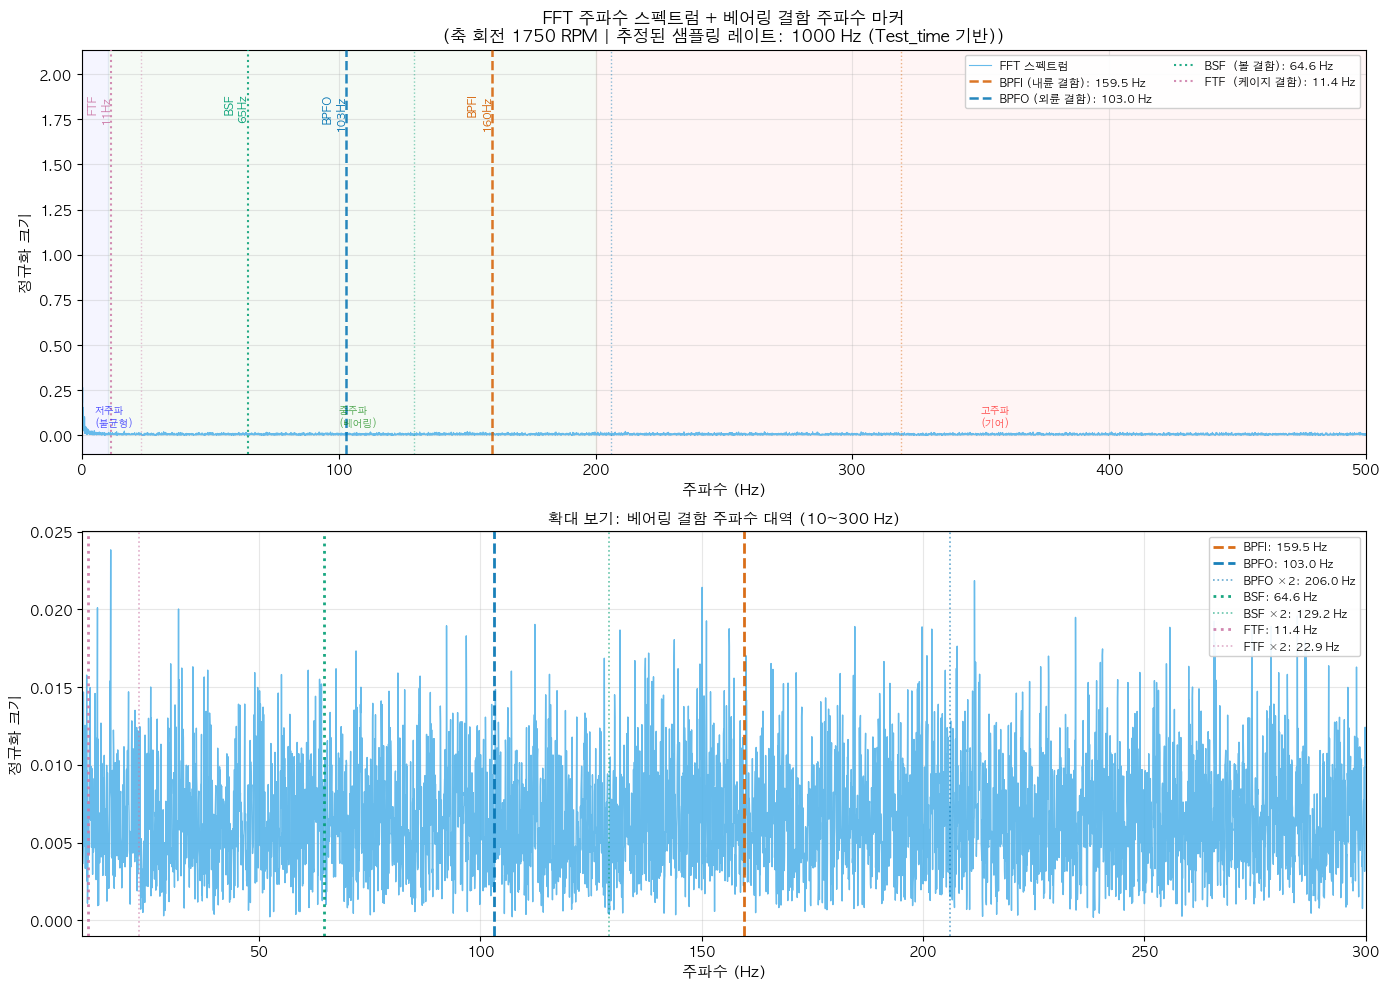


🔍 스펙트럼 해석 가이드:
   파선(--): 각 결함 유형의 기본 주파수
   점선(·· ): 2배 고조파 (결함 시 에너지가 집중되는 경향)
   📌 실제 결함이 있으면: 해당 수직선 위치에 뾰족한 피크가 나타남
   📌 정상 베어링:        수직선 위치에 특별한 피크 없음


In [7]:

# ============================================================
# 📊 FFT 스펙트럼 시각화 (베어링 결함 주파수 마커 포함)
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform

# --- OS별 한글 폰트 설정 ---
def setup_korean_font():
    system = platform.system()
    try:
        import google.colab
        import subprocess
        subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
        fm._load_fontmanager(try_read_cache=False)
        plt.rcParams['font.family'] = 'NanumGothic'
    except ImportError:
        if system == 'Darwin':
            plt.rcParams['font.family'] = 'AppleGothic'
        elif system == 'Linux':
            nanum = [f for f in fm.fontManager.ttflist if 'Nanum' in f.name]
            if nanum:
                plt.rcParams['font.family'] = 'NanumGothic'
        elif system == 'Windows':
            plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False

setup_korean_font()

# 색맹 친화적 팔레트 (Okabe-Ito)
C = {
    'spectrum': '#56B4E9',   # 하늘색 - FFT 스펙트럼
    'bpfi':     '#D55E00',   # 주황색 - 내륜 결함
    'bpfo':     '#0072B2',   # 파란색 - 외륜 결함
    'bsf':      '#009E73',   # 초록색 - 볼 결함
    'ftf':      '#CC79A7',   # 분홍색 - 케이지 결함
    'peak':     '#E69F00',   # 노란색 - 피크
}

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- 상단: 전체 스펙트럼 + 결함 주파수 마커 ---
ax1 = axes[0]
ax1.plot(frequencies, magnitudes_normalized, linewidth=0.8,
         color=C['spectrum'], label='FFT 스펙트럼', alpha=0.9, zorder=2)

# 결함 주파수 수직선 표시 (fault_freqs는 cell-7에서 계산됨)
fault_line_styles = {
    'BPFI (내륜 결함)':  (C['bpfi'], '--', 1.8),
    'BPFO (외륜 결함)':  (C['bpfo'], '--', 1.8),
    'BSF  (볼 결함)':    (C['bsf'],  ':',  1.5),
    'FTF  (케이지 결함)': (C['ftf'],  ':',  1.5),
}

ymax = magnitudes_normalized.max()
for name, freq in fault_freqs.items():
    color, ls, lw = fault_line_styles.get(name, ('#999999', '--', 1.0))
    short = name.split()[0]  # 'BPFI', 'BPFO', 'BSF', 'FTF'
    # 기본 주파수
    ax1.axvline(x=freq, color=color, linestyle=ls, linewidth=lw,
                alpha=0.85, label=f'{name}: {freq:.1f} Hz', zorder=3)
    # 2배 고조파 (점선)
    ax1.axvline(x=freq*2, color=color, linestyle=':', linewidth=1.0,
                alpha=0.45, zorder=3)
    # 레이블
    if freq < nyquist * 0.9:
        ax1.text(freq, ymax * 0.93, f'{short}\n{freq:.0f}Hz',
                 rotation=90, va='top', ha='right', fontsize=8,
                 color=color, fontweight='bold')

ax1.set_title(f'FFT 주파수 스펙트럼 + 베어링 결함 주파수 마커\n'
              f'(축 회전 {SHAFT_RPM} RPM | {SR_NOTE})', fontsize=12, fontweight='bold')
ax1.set_xlabel('주파수 (Hz)', fontsize=11)
ax1.set_ylabel('정규화 크기', fontsize=11)
ax1.set_xlim(0, min(nyquist, 500))
ax1.legend(loc='upper right', fontsize=8, framealpha=0.92, ncol=2)
ax1.grid(alpha=0.3)

# 주파수 대역 배경 (교육용)
ax1.axvspan(0,   10,  alpha=0.04, color='blue')
ax1.axvspan(10, 200,  alpha=0.04, color='green')
ax1.axvspan(200, 500, alpha=0.04, color='red')

for band, x, color in [('저주파\n(불균형)', 5, 'blue'),
                        ('중주파\n(베어링)', 100, 'green'),
                        ('고주파\n(기어)', 350, 'red')]:
    ax1.text(x, ymax*0.02, band, fontsize=7, color=color, alpha=0.7, va='bottom')

# --- 하단: 결함 주파수 대역 확대 ---
ax2 = axes[1]
# 결함 주파수가 주로 분포하는 10~300 Hz 대역 확대
freq_mask = (frequencies >= 10) & (frequencies <= 300)
ax2.plot(frequencies[freq_mask], magnitudes_normalized[freq_mask],
         linewidth=1.0, color=C['spectrum'], alpha=0.9)

for name, freq in fault_freqs.items():
    color, ls, lw = fault_line_styles.get(name, ('#999999', '--', 1.0))
    if 10 <= freq <= 300:
        ax2.axvline(x=freq, color=color, linestyle=ls, linewidth=2.0,
                    alpha=0.9, label=f'{name.split()[0]}: {freq:.1f} Hz')
    if 10 <= freq*2 <= 300:
        ax2.axvline(x=freq*2, color=color, linestyle=':', linewidth=1.2,
                    alpha=0.6, label=f'{name.split()[0]} ×2: {freq*2:.1f} Hz')

ax2.set_title('확대 보기: 베어링 결함 주파수 대역 (10~300 Hz)', fontsize=11, fontweight='bold')
ax2.set_xlabel('주파수 (Hz)', fontsize=11)
ax2.set_ylabel('정규화 크기', fontsize=11)
ax2.set_xlim(10, 300)
ax2.legend(loc='upper right', fontsize=8, framealpha=0.92)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🔍 스펙트럼 해석 가이드:")
print("   파선(--): 각 결함 유형의 기본 주파수")
print("   점선(·· ): 2배 고조파 (결함 시 에너지가 집중되는 경향)")
print("   📌 실제 결함이 있으면: 해당 수직선 위치에 뾰족한 피크가 나타남")
print("   📌 정상 베어링:        수직선 위치에 특별한 피크 없음")


## 🎯 Step 5: 지배 주파수 (Dominant Frequency) 찾기

In [8]:
# Peak 검출
# 최소 높이 설정 (평균의 2배)
threshold = magnitudes_normalized.mean() * 2
peaks, properties = find_peaks(magnitudes_normalized, height=threshold, distance=10)

# 상위 10개 주파수 추출
top_n = min(10, len(peaks))
top_peak_indices = peaks[np.argsort(magnitudes_normalized[peaks])[-top_n:][::-1]]

print(f"🎯 지배 주파수 (상위 {top_n}개):")
print(f"\n{'순위':<5} {'주파수 (Hz)':<15} {'크기':<15} {'설명'}")
print("-" * 60)

for rank, peak_idx in enumerate(top_peak_indices, 1):
    freq = frequencies[peak_idx]
    mag = magnitudes_normalized[peak_idx]
    
    # 주파수 대역 분류
    if freq < 10:
        desc = "저주파 (회전 불균형)"
    elif freq < 100:
        desc = "중주파 (베어링 결함)"
    elif freq < 1000:
        desc = "고주파 (기어 결함)"
    else:
        desc = "초고주파 (공진)"
    
    print(f"{rank:<5} {freq:<15.2f} {mag:<15.6f} {desc}")

# 가장 지배적인 주파수
dominant_freq = frequencies[top_peak_indices[0]]
dominant_mag = magnitudes_normalized[top_peak_indices[0]]

print(f"\n⭐ 가장 지배적인 주파수: {dominant_freq:.2f} Hz (크기: {dominant_mag:.6f})")

🎯 지배 주파수 (상위 10개):

순위    주파수 (Hz)        크기              설명
------------------------------------------------------------
1     0.24            0.265158        저주파 (회전 불균형)
2     0.98            0.102909        저주파 (회전 불균형)
3     1.65            0.045309        저주파 (회전 불균형)
4     2.44            0.033203        저주파 (회전 불균형)
5     4.76            0.025974        저주파 (회전 불균형)
6     3.05            0.024981        저주파 (회전 불균형)
7     3.85            0.024816        저주파 (회전 불균형)
8     16.48           0.023821        중주파 (베어링 결함)
9     211.61          0.021843        고주파 (기어 결함)
10    150.09          0.021410        고주파 (기어 결함)

⭐ 가장 지배적인 주파수: 0.24 Hz (크기: 0.265158)


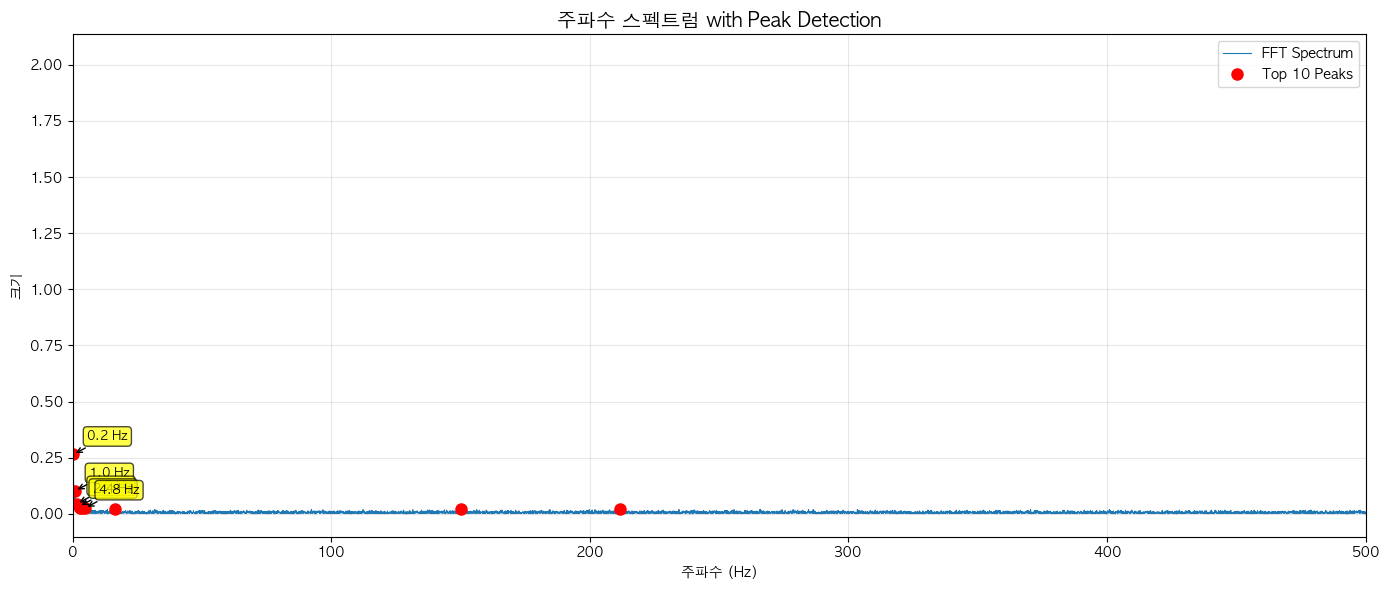

In [9]:
# Peak 표시된 FFT 스펙트럼
plt.figure(figsize=(14, 6))
plt.plot(frequencies, magnitudes_normalized, linewidth=0.8, label='FFT Spectrum')
plt.plot(frequencies[top_peak_indices], magnitudes_normalized[top_peak_indices], 
         'ro', markersize=8, label=f'Top {top_n} Peaks')

# 지배 주파수에 레이블 추가
for peak_idx in top_peak_indices[:5]:  # 상위 5개만
    freq = frequencies[peak_idx]
    mag = magnitudes_normalized[peak_idx]
    plt.annotate(f'{freq:.1f} Hz', 
                xy=(freq, mag), 
                xytext=(10, 10), 
                textcoords='offset points',
                fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.title('주파수 스펙트럼 with Peak Detection', fontsize=14, fontweight='bold')
plt.xlabel('주파수 (Hz)')
plt.ylabel('크기')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(0, sampling_rate / 2)
plt.tight_layout()
plt.show()

## 🚨 Step 6: 이상 주파수 탐지

In [10]:
# 이상 주파수 기준 설정
# 방법 1: 통계적 임계값 (평균 + 3*표준편차)
mean_mag = magnitudes_normalized.mean()
std_mag = magnitudes_normalized.std()
anomaly_threshold = mean_mag + 3 * std_mag

# 이상치 검출
anomaly_indices = np.where(magnitudes_normalized > anomaly_threshold)[0]
anomaly_freqs = frequencies[anomaly_indices]
anomaly_mags = magnitudes_normalized[anomaly_indices]

print(f"🚨 이상 주파수 탐지 결과:")
print(f"   임계값: {anomaly_threshold:.6f} (평균 + 3σ)")
print(f"   이상 주파수 개수: {len(anomaly_freqs)}개")

if len(anomaly_freqs) > 0:
    print(f"\n📊 이상 주파수 목록 (상위 10개):")
    top_anomalies = min(10, len(anomaly_freqs))
    sorted_indices = np.argsort(anomaly_mags)[-top_anomalies:][::-1]
    
    print(f"\n{'순위':<5} {'주파수 (Hz)':<15} {'크기':<15} {'위험도'}")
    print("-" * 60)
    
    for rank, idx in enumerate(sorted_indices, 1):
        freq = anomaly_freqs[idx]
        mag = anomaly_mags[idx]
        risk = "🔴 높음" if mag > mean_mag + 5*std_mag else "🟡 중간"
        print(f"{rank:<5} {freq:<15.2f} {mag:<15.6f} {risk}")
else:
    print("\n✅ 이상 주파수 없음")

🚨 이상 주파수 탐지 결과:
   임계값: 0.085054 (평균 + 3σ)
   이상 주파수 개수: 10개

📊 이상 주파수 목록 (상위 10개):

순위    주파수 (Hz)        크기              위험도
------------------------------------------------------------
1     0.00            2.033744        🔴 높음
2     0.06            1.000255        🔴 높음
3     0.12            0.343884        🔴 높음
4     0.24            0.265158        🔴 높음
5     0.18            0.180608        🔴 높음
6     0.37            0.155061        🔴 높음
7     0.55            0.119597        🟡 중간
8     0.43            0.118688        🟡 중간
9     0.98            0.102909        🟡 중간
10    1.04            0.093146        🟡 중간


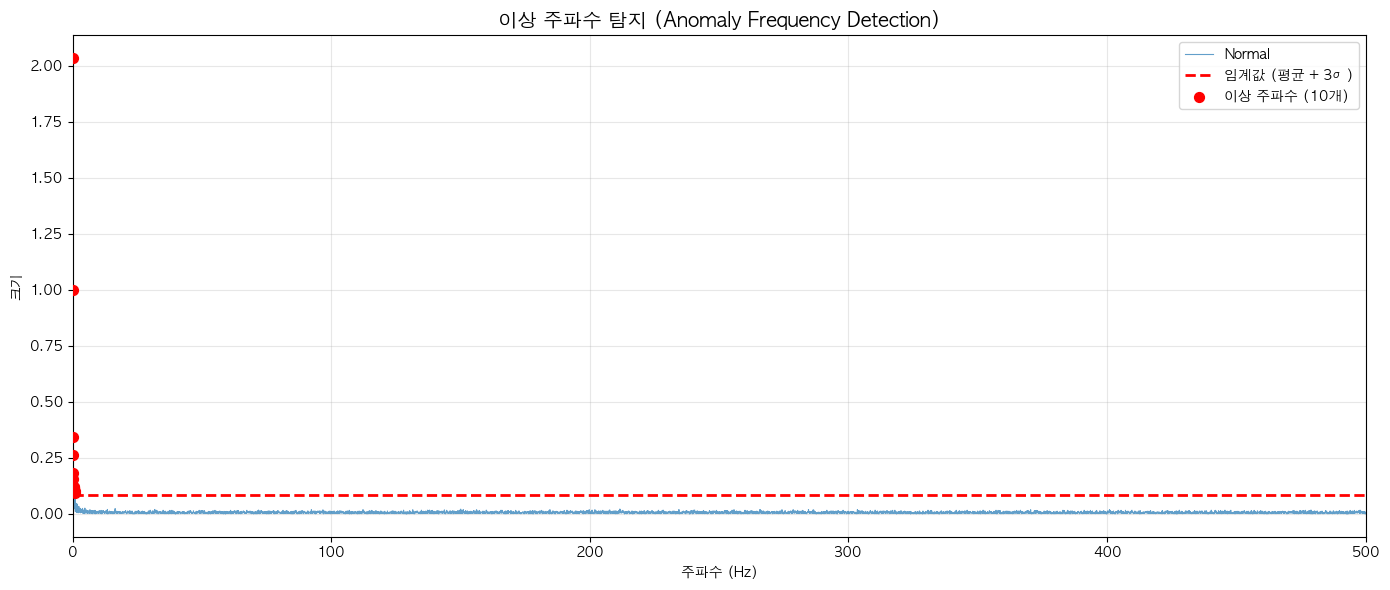


💡 이상 주파수 의미:
   - 예상치 못한 고주파: 공진, 느슨한 부품
   - 비정상적 저주파: 회전 불균형, 미스얼라인먼트
   - 특정 주파수 급증: 베어링 결함, 기어 마모


In [11]:
# 이상 주파수 시각화
plt.figure(figsize=(14, 6))
plt.plot(frequencies, magnitudes_normalized, linewidth=0.8, label='Normal', alpha=0.7)
plt.axhline(y=anomaly_threshold, color='r', linestyle='--', label=f'임계값 (평균 + 3σ)', linewidth=2)

if len(anomaly_freqs) > 0:
    plt.scatter(anomaly_freqs, anomaly_mags, color='red', s=50, 
               label=f'이상 주파수 ({len(anomaly_freqs)}개)', zorder=5)

plt.title('이상 주파수 탐지 (Anomaly Frequency Detection)', fontsize=14, fontweight='bold')
plt.xlabel('주파수 (Hz)')
plt.ylabel('크기')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(0, sampling_rate / 2)
plt.tight_layout()
plt.show()

print("\n💡 이상 주파수 의미:")
print("   - 예상치 못한 고주파: 공진, 느슨한 부품")
print("   - 비정상적 저주파: 회전 불균형, 미스얼라인먼트")
print("   - 특정 주파수 급증: 베어링 결함, 기어 마모")

## 📊 Step 7: Spectrogram (시간-주파수 분석)

In [12]:
# Spectrogram 계산
print("🔄 Spectrogram 계산 중...")

# 신호 길이 제한 (메모리 효율)
signal_sample = signal[:min(10000, len(signal))]

frequencies_spec, times_spec, Sxx = spectrogram(
    signal_sample, 
    fs=sampling_rate,
    nperseg=256,  # 윈도우 크기
    noverlap=128  # 오버랩
)

print(f"✅ Spectrogram 완료!")
print(f"   시간 분할: {len(times_spec)}개")
print(f"   주파수 분할: {len(frequencies_spec)}개")
print(f"   시간 범위: [0, {times_spec.max():.2f}]초")
print(f"   주파수 범위: [0, {frequencies_spec.max():.2f}]Hz")

🔄 Spectrogram 계산 중...
✅ Spectrogram 완료!
   시간 분할: 77개
   주파수 분할: 129개
   시간 범위: [0, 9.86]초
   주파수 범위: [0, 500.00]Hz


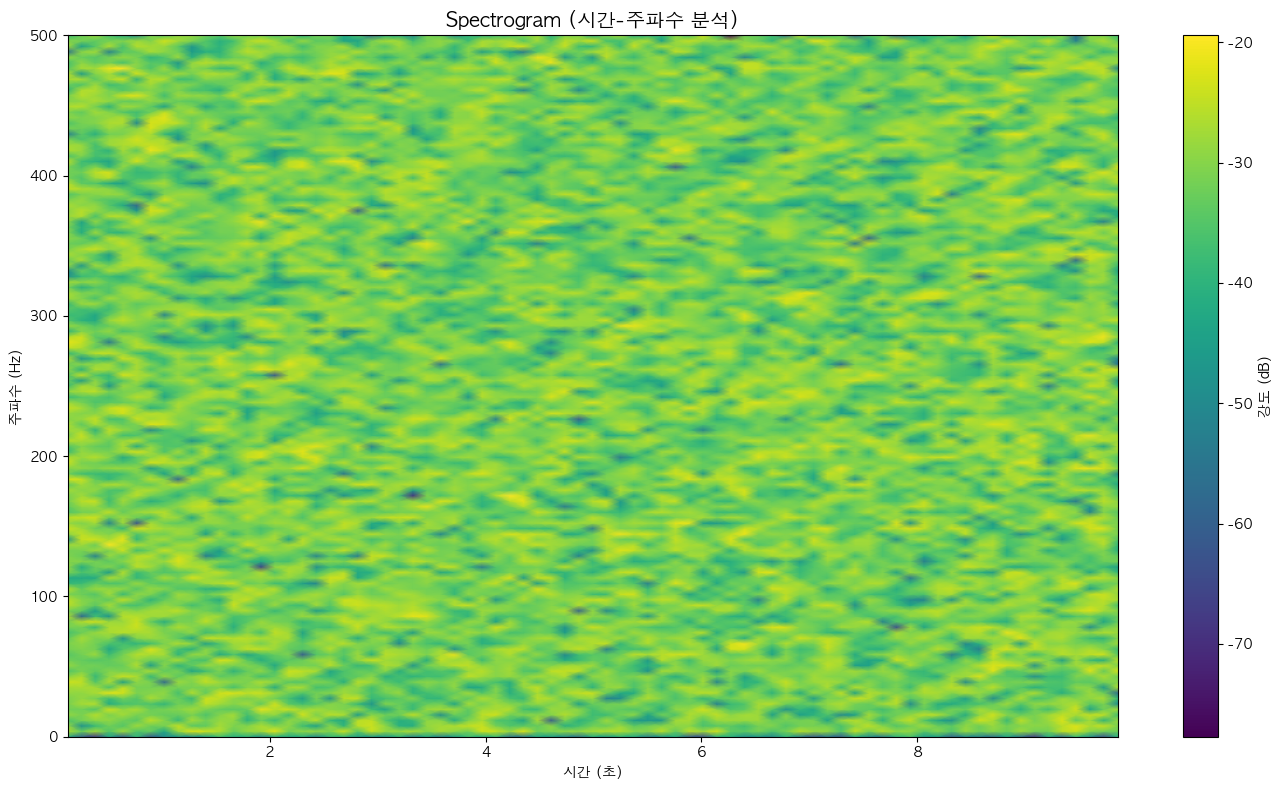


💡 Spectrogram 해석:
   - X축: 시간
   - Y축: 주파수
   - 색상: 에너지 강도 (밝을수록 강함)
   - 패턴: 주파수가 시간에 따라 어떻게 변하는지 관찰
   - 활용: 비정상 주파수 발생 시점 파악


In [13]:
# Spectrogram 시각화
plt.figure(figsize=(14, 8))
plt.pcolormesh(times_spec, frequencies_spec, 10 * np.log10(Sxx + 1e-10), 
               shading='gouraud', cmap='viridis')
plt.colorbar(label='강도 (dB)')
plt.title('Spectrogram (시간-주파수 분석)', fontsize=14, fontweight='bold')
plt.xlabel('시간 (초)')
plt.ylabel('주파수 (Hz)')
plt.ylim(0, sampling_rate / 2)
plt.tight_layout()
plt.show()

print("\n💡 Spectrogram 해석:")
print("   - X축: 시간")
print("   - Y축: 주파수")
print("   - 색상: 에너지 강도 (밝을수록 강함)")
print("   - 패턴: 주파수가 시간에 따라 어떻게 변하는지 관찰")
print("   - 활용: 비정상 주파수 발생 시점 파악")

## 💾 Step 8: 결과 저장

In [14]:
# 출력 디렉토리 생성
output_dir = Path('../outputs')
output_dir.mkdir(exist_ok=True)

# 1. 지배 주파수 저장
dominant_freqs_df = pd.DataFrame({
    'rank': range(1, len(top_peak_indices) + 1),
    'frequency_hz': frequencies[top_peak_indices],
    'magnitude': magnitudes_normalized[top_peak_indices]
})
dominant_file = output_dir / '02_dominant_frequencies.csv'
dominant_freqs_df.to_csv(dominant_file, index=False, encoding='utf-8-sig')
print(f"✅ 지배 주파수 저장: {dominant_file}")

# 2. 이상 주파수 저장
if len(anomaly_freqs) > 0:
    anomaly_df = pd.DataFrame({
        'frequency_hz': anomaly_freqs,
        'magnitude': anomaly_mags
    }).sort_values('magnitude', ascending=False)
    anomaly_file = output_dir / '02_anomaly_frequencies.csv'
    anomaly_df.to_csv(anomaly_file, index=False, encoding='utf-8-sig')
    print(f"✅ 이상 주파수 저장: {anomaly_file}")
else:
    print("⚠️ 이상 주파수 없음 (저장 생략)")

# 3. FFT 스펙트럼 저장 (NumPy)
fft_file = output_dir / '02_fft_spectrum.npz'
np.savez(fft_file, 
         frequencies=frequencies, 
         magnitudes=magnitudes_normalized,
         sampling_rate=sampling_rate)
print(f"✅ FFT 스펙트럼 저장: {fft_file}")

# 4. 분석 요약 저장
summary = pd.DataFrame({
    '항목': ['샘플링 레이트', '샘플 수', '총 시간', '주파수 해상도', 
            '지배 주파수', '이상 주파수 개수', '임계값'],
    '값': [
        f"{sampling_rate} Hz",
        f"{n_samples:,}개",
        f"{duration:.2f}초",
        f"{frequencies[1]:.4f} Hz",
        f"{dominant_freq:.2f} Hz",
        f"{len(anomaly_freqs)}개",
        f"{anomaly_threshold:.6f}"
    ]
})
summary_file = output_dir / '02_fft_analysis_summary.csv'
summary.to_csv(summary_file, index=False, encoding='utf-8-sig')
print(f"✅ 분석 요약 저장: {summary_file}")

print("\n🎉 FFT 주파수 분석 완료!")

✅ 지배 주파수 저장: ../outputs/02_dominant_frequencies.csv


✅ 이상 주파수 저장: ../outputs/02_anomaly_frequencies.csv
✅ FFT 스펙트럼 저장: ../outputs/02_fft_spectrum.npz
✅ 분석 요약 저장: ../outputs/02_fft_analysis_summary.csv

🎉 FFT 주파수 분석 완료!


---

## 🎯 학습 정리

### ✅ 완료한 내용
1. FFT로 시계열 진동 신호를 주파수 도메인으로 변환
2. 주파수 스펙트럼 시각화 및 해석
3. Peak Detection으로 지배 주파수 추출
4. 통계적 방법으로 이상 주파수 탐지
5. Spectrogram으로 시간-주파수 분석
6. 분석 결과 저장 및 문서화

### 💡 핵심 인사이트
- **FFT의 장점**:
  - 시계열에서 보이지 않던 주파수 패턴 발견
  - 특정 주파수 성분 분리 및 분석
  - 설비 결함 조기 진단 (베어링, 기어, 회전 불균형)

- **주파수 대역별 의미**:
  - **저주파 (<10Hz)**: 회전 불균형, 미스얼라인먼트
  - **중주파 (10-100Hz)**: 베어링 결함, 구조적 공진
  - **고주파 (100-1000Hz)**: 기어 결함, 벨트 문제
  - **초고주파 (>1000Hz)**: 공진, 느슨한 부품

- **이상 탐지 방법**:
  - 3-sigma 규칙: 평균 + 3×표준편차
  - 정상 운전 데이터와 비교
  - 시간에 따른 주파수 변화 추적 (Spectrogram)

- **실무 적용**:
  - 예지보전: 고장 전 징후 감지
  - 품질 관리: 진동 기준 초과 탐지
  - 근본 원인 분석: 특정 주파수로 결함 위치 파악

### 📚 다음 단계
- **03_anomaly_detection.ipynb**: 머신러닝 기반 이상 탐지
- **Part 2-2**: Vision Transformer (ViT) 활용

### 🔗 참고 자료
- [FFT 개념 이해](https://en.wikipedia.org/wiki/Fast_Fourier_transform)
- [진동 분석 가이드](https://www.azosensors.com/article.aspx?ArticleID=1467)
- [SciPy FFT 문서](https://docs.scipy.org/doc/scipy/tutorial/fft.html)

---

*제조AI 교육 v12 Enhanced | Part 2-1 | 2025.02*